In [188]:
# Enable automatic reloading of imported modules when their source changes
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import numpy as np
from waxa import atomdata
from waxa.plotting import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [189]:
# ad = atomdata(62825,'andor_all')
ad = atomdata(65000,'andor_all')

65000
[atomdata timing] load total=6.372s | get_data_file(initial)=2.633s | h5_open=0.011s | headers=0.031s | core_arrays=0.596s | datavault=0.001s | scope_data=3.098s
No ROI saved in run 65000 (cached).
ROI specified by string. Referencing roi.xslx spreadsheet (PotassiumData)...
ROI andor_all found.
[atomdata timing] init total=10.740s | load_data=6.372s | setup+roi=0.003s | unshuffle_old=0.000s | initial_analysis=4.365s


In [190]:
print(ad.params.amp_imaging)

0.47241379310344833


65000


Text(0.5, 1.0, 'Run 65000')

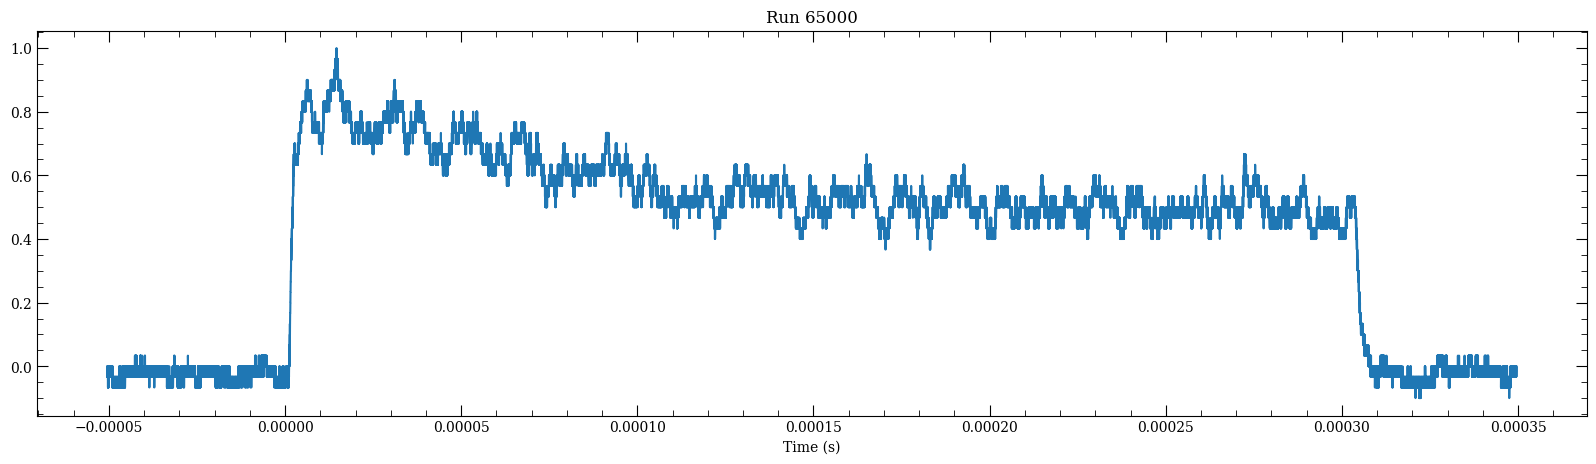

In [191]:
trace = ad.scope_data['PD'][0]

cuton = 0
cutoff = 800000

fig, axes = plt.subplots(1, figsize=[20,5])

print(ad.run_info.run_id)
idx = 2
axes.plot(trace.t[idx][cuton:cutoff],trace.v[idx][cuton:cutoff])
axes.set_xlabel('Time (s)')
plt.title(f'Run {ad.run_info.run_id}')

In [192]:
print(np.std(trace.v[idx][cuton:cutoff]))

0.2697386


In [193]:
# Average repeats together into new array (works only for 1d xvar scan)

print(np.shape(trace.v)[0]/ad.params.N_repeats)

averaged_traces = np.zeros((int(np.shape(trace.v)[0]/ad.params.N_repeats),np.shape(trace.v)[1]))

for n in range(0,np.shape(trace.v)[0],ad.params.N_repeats):
    sum_trace = np.zeros((np.shape(trace.v)[1]))
    for t in range(ad.params.N_repeats):
        t = t + n
        sum_trace = trace.v[t] + sum_trace
    averaged_traces[int(n/ad.params.N_repeats)] = sum_trace / ad.params.N_repeats

13.0


65000


Text(0.5, 1.0, 'Run 65000')

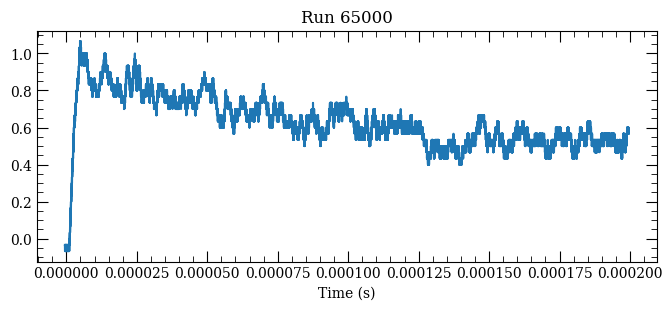

In [194]:
cuton = 100000
cutoff = 500000

fig, axes = plt.subplots(1, figsize=[8,3])

print(ad.run_info.run_id)
idx = 0
axes.plot(trace.t[idx][cuton:cutoff],trace.v[idx][cuton:cutoff])
# axes.set_ylim(0.,4.5)
# axes.set_xlim(0.,30.e-6)
axes.set_xlabel('Time (s)')
plt.title(f'Run {ad.run_info.run_id}')

In [195]:
import numpy as np
import matplotlib.pyplot as plt
import math

def plot_traces_grid(averaged_traces, x, labels=None, ncols=None, figsize=(12,8),
                     decimate=None, sharex=True, sharey=False, suptitle=None, xlabel=None,
                     ylim = None, xlim = None):
    """
    Plot each row of averaged_traces as a subplot in a grid.

    averaged_traces: (N, M) array where N=number of traces (20), M=points
    x: 1D x axis array with length M (e.g., trace.t[0])
    labels: list/array of length N with subplot labels (can be None)
    ncols: number of columns in grid (auto if None)
    figsize: figure size
    decimate: int or None — if int>1, plot every decimate-th sample to speed up
    sharex/sharey: whether to share axes
    suptitle: optional overall title
    """
    N = averaged_traces.shape[0]
    if labels is None:
        labels = [f"Trace {i}" for i in range(N)]
    if ncols is None:
        ncols = int(math.ceil(math.sqrt(N)))
    nrows = int(math.ceil(N / ncols))

    if decimate is not None and decimate > 1:
        x = x[::decimate]
    
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, sharex=sharex, sharey=sharey)
    axes = np.array(axes).reshape(-1)  # flatten to 1D for easy indexing

    for i in range(nrows * ncols):
        ax = axes[i]
        if i < N:
            trace = averaged_traces[i]
            if decimate is not None and decimate > 1:
                trace = trace[::decimate]
            ax.plot(x, trace, lw=0.8)
            ax.set_title(labels[i], fontsize=10)
            ax.grid(True, alpha=0.3)
            if ylim is not None:
                ax.set_ylim(ylim[0],ylim[1])
            if xlim is not None:
                ax.set_xlim(xlim[0],xlim[1])
        else:
            ax.axis('off')  # turn off unused subplots

    if suptitle:
        fig.suptitle(suptitle)
    # single x-label (prefer supxlabel when available)
    if xlabel is not None:
        if hasattr(fig, "supxlabel"):
            fig.supxlabel(xlabel)
        else:
            fig.text(0.5, 0.02, xlabel, ha='center', fontsize=11)

    # leave room for labels/title
    fig.tight_layout(rect=[0.03, 0.01, 1, 0.99])
    plt.show()
    return fig, axes[:N]



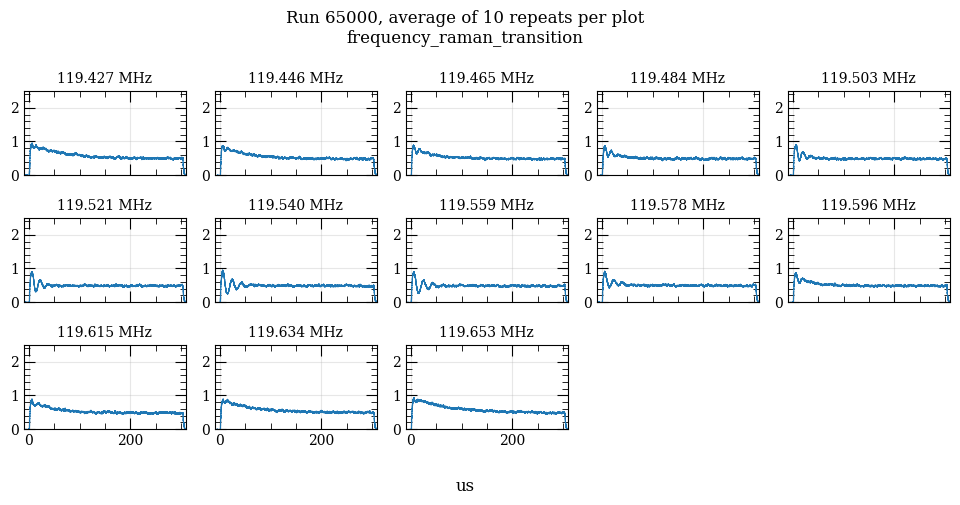

In [196]:
# Example usage:
# averaged_traces is (20, 200000), trace.t[0] is length 200000

xvarunit, xvarmult, xvarname = detect_unit(ad, 0, xvarunit="", xvarmult=1.)
labels = [f"{ad.xvars[0][i * ad.params.N_repeats]*xvarmult:.3f} {xvarunit}" for i in range(int(ad.xvardims[0]/ad.p.N_repeats))]
fig, axes = plot_traces_grid(averaged_traces, trace.t[0]*1.e6, labels=labels, ncols=5, decimate=None, figsize=(10,5),
                             suptitle=f'Run {ad.run_info.run_id}, average of {ad.params.N_repeats} repeats per plot\n' +
                             f'{ad.xvarnames[0]}',
                             xlabel='us',
                             ylim=[.0,2.5],xlim=[-10.,310])

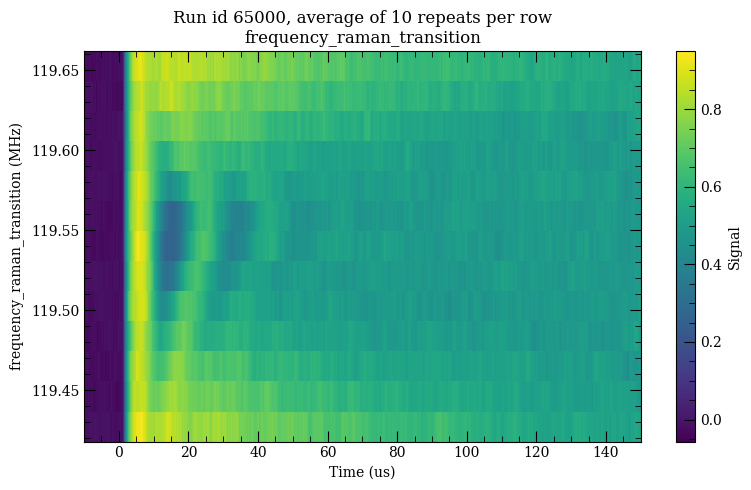

In [206]:

t_us = trace.t[0] * 1e6

# x variable info
xvarunit, xvarmult, xvarname = detect_unit(ad, 0, xvarunit="", xvarmult=1.)

xvals = np.array([
    ad.xvars[0][i * ad.params.N_repeats] * xvarmult
    for i in range(int(ad.xvardims[0] / ad.params.N_repeats))
])

ncurves = min(len(averaged_traces), len(xvals))
Z = np.asarray(averaged_traces[:ncurves])
xvals = xvals[:ncurves]

tmin = -10
tmax = 150
mask_t = (t_us >= tmin) & (t_us <= tmax)

t_plot = t_us[mask_t]
Z_plot = Z[:, mask_t]

fig, ax = plt.subplots(figsize=(8, 5))

im = ax.pcolormesh(
    t_plot,
    xvals,
    Z_plot,
    shading="auto"
)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Signal")

ax.set_xlabel("Time (us)")
ax.set_ylabel(f"{xvarname} ({xvarunit})" if xvarunit else xvarname)

ax.set_title(
    f"Run id {ad.run_info.run_id}, average of {ad.params.N_repeats} repeats per row\n"
    f"{ad.xvarnames[0]}"
)

plt.tight_layout()
plt.show()

### try other model

In [135]:
import pandas as pd
from scipy.optimize import curve_fit

def fit_model_1(t, A, Omega, tau, phi, C):
    # return A * np.exp(-t / tau) * np.cos(Omega * t + phi) + C
    return (A * np.exp(-t / tau) * np.cos(Omega * t + phi) + C)**2

In [136]:
t_us = trace.t[0] * 1e6

xvarunit, xvarmult, xvarname = detect_unit(ad, 0, xvarunit="", xvarmult=1.)

labels = [
    f"{ad.xvars[0][i * ad.params.N_repeats] * xvarmult:.3f} {xvarunit}"
    for i in range(int(ad.xvardims[0] / ad.params.N_repeats))
]

xvals = np.array([
    ad.xvars[0][i * ad.params.N_repeats] * xvarmult
    for i in range(int(ad.xvardims[0] / ad.params.N_repeats))
], dtype=float)

ncurves = min(len(averaged_traces), len(labels))
averaged_traces_use = np.asarray(averaged_traces[:ncurves])
labels_use = labels[:ncurves]
xvals_use = xvals[:ncurves]


def fit_single_model_1(t, y, tmin=0, tmax=300):
    mask = (t >= tmin) & (t <= tmax)
    t_fit = t[mask]
    y_fit = y[mask]

    C0 = np.median(y_fit[-max(10, len(y_fit)//10):])
    A0 = y_fit[0] - C0
    tau0 = max((t_fit[-1] - t_fit[0]) / 5, 1.0)
    Omega0 = 2 * np.pi / 20.0
    phi0 = 0.0

    p0 = [A0, Omega0, tau0, phi0, C0]

    bounds = (
        [-np.inf, 0.05, 1e-6, -2*np.pi, -np.inf],
        [ np.inf, 2.0,  np.inf,  2*np.pi,  np.inf]
    )

    popt, pcov = curve_fit(
        fit_model_1,
        t_fit,
        y_fit,
        p0=p0,
        bounds=bounds,
        maxfev=100000
    )

    perr = np.sqrt(np.diag(pcov))
    return popt, pcov, perr, t_fit, y_fit


all_results_1 = []
rows_1 = []

for i, y in enumerate(averaged_traces_use):
    try:
        popt, pcov, perr, t_fit, y_fit = fit_single_model_1(
            t_us,
            y,
            tmin=0,
            tmax=300
        )

        A, Omega, tau, phi, C = popt
        A_err, Omega_err, tau_err, phi_err, C_err = perr

        all_results_1.append({
            "success": True,
            "popt": popt,
            "pcov": pcov,
            "perr": perr
        })

        rows_1.append({
            "index": i,
            "label": labels_use[i],
            "xval": xvals_use[i],
            "A": A,
            "Omega": Omega,
            "tau_us": tau,
            "phi": phi,
            "C": C,
            "A_err": A_err,
            "Omega_err": Omega_err,
            "tau_us_err": tau_err,
            "phi_err": phi_err,
            "C_err": C_err,
            "f_MHz": Omega / (2*np.pi),
            "f_MHz_err": Omega_err / (2*np.pi),
        })

    except Exception as e:
        all_results_1.append({
            "success": False,
            "popt": None,
            "pcov": None,
            "perr": None,
            "error": str(e)
        })

        rows_1.append({
            "index": i,
            "label": labels_use[i],
            "xval": xvals_use[i],
            "A": np.nan,
            "Omega": np.nan,
            "tau_us": np.nan,
            "phi": np.nan,
            "C": np.nan,
            "A_err": np.nan,
            "Omega_err": np.nan,
            "tau_us_err": np.nan,
            "phi_err": np.nan,
            "C_err": np.nan,
            "f_MHz": np.nan,
            "f_MHz_err": np.nan,
        })

df_fit_1 = pd.DataFrame(rows_1)
print(df_fit_1)

    index        label        xval         A     Omega     tau_us       phi  \
0       0  119.427 MHz  119.427423 -0.969459  0.050000  15.850413  1.414887   
1       1  119.446 MHz  119.446205 -1.020873  0.050000  14.207700  1.406104   
2       2  119.465 MHz  119.464986  1.345096  0.050000  10.473125  4.559563   
3       3  119.484 MHz  119.483768 -5.989752  0.050000   3.761360  1.438609   
4       4  119.503 MHz  119.502550 -0.613825  0.419057   7.266233  0.459246   
5       5  119.521 MHz  119.521331 -0.467641  0.394626  12.679969  0.512680   
6       6  119.540 MHz  119.540113 -0.415622  0.357109  18.481930  0.703836   
7       7  119.559 MHz  119.558895  0.400019  0.346828  18.038948 -2.413883   
8       8  119.578 MHz  119.577676  0.951308  0.331447   4.956158 -2.428496   
9       9  119.596 MHz  119.596458  5.886310  0.050000   3.833459 -1.702733   
10     10  119.615 MHz  119.615240 -1.021416  0.050000  13.598452  1.413571   
11     11  119.634 MHz  119.634021 -1.138579  0.0500

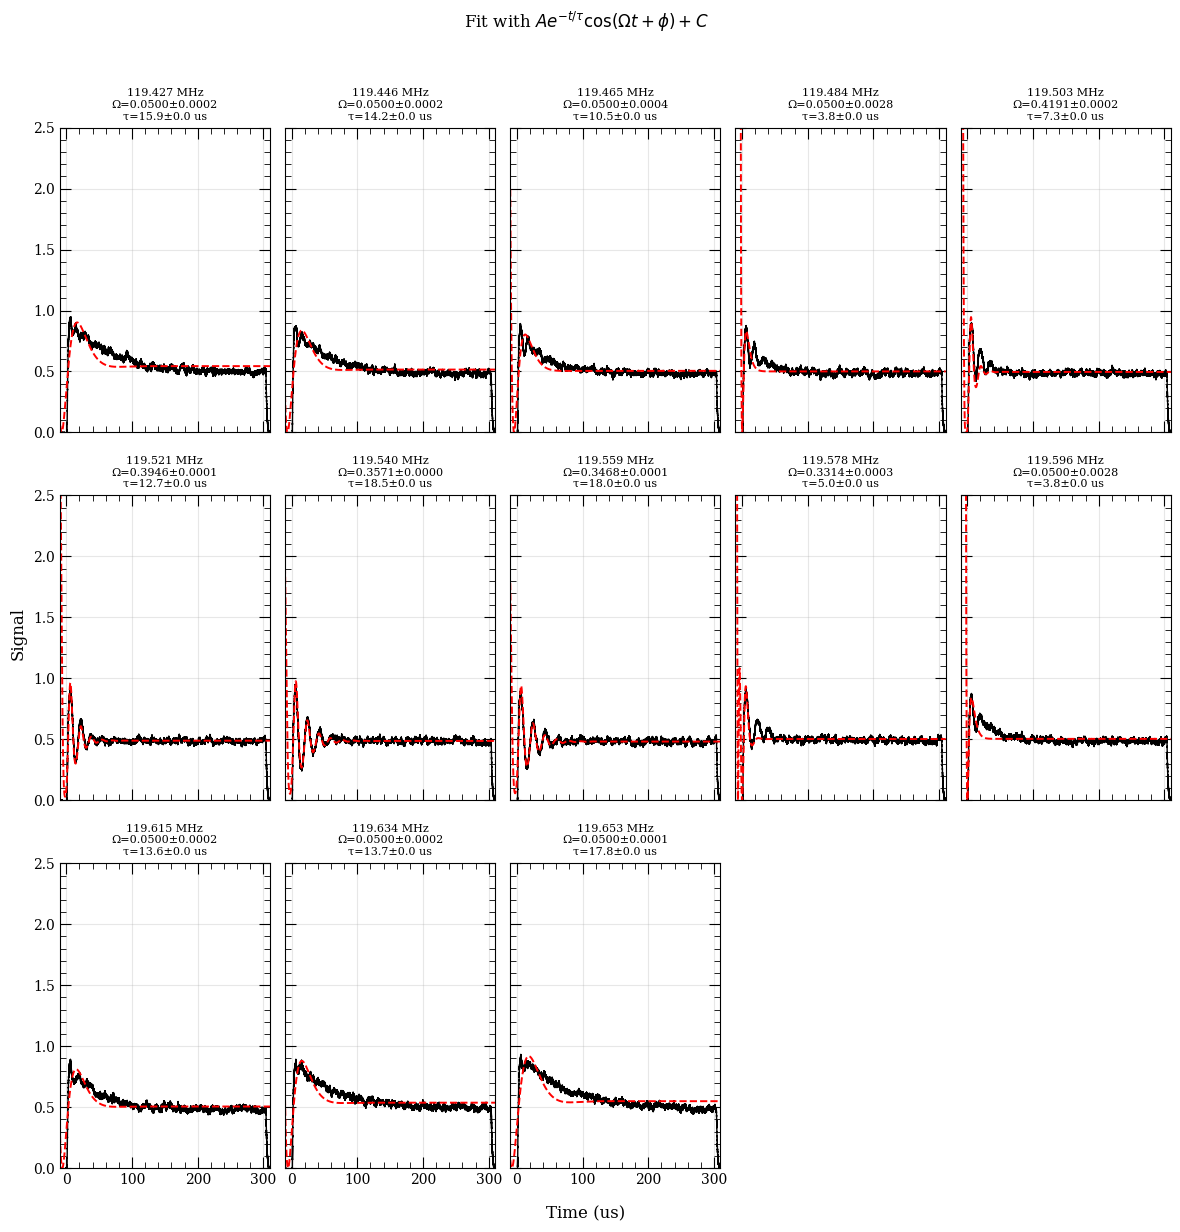

In [138]:
ncols = 5
nrows = int(np.ceil(ncurves / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 12), sharex=True, sharey=True)
axes = np.ravel(axes)

for i, y in enumerate(averaged_traces_use):
    ax = axes[i]

    ax.plot(t_us, y, color="k", lw=1.0, label="data")

    if all_results_1[i]["success"]:
        popt = all_results_1[i]["popt"]
        perr = all_results_1[i]["perr"]

        y_model = fit_model_1(t_us, *popt)
        ax.plot(t_us, y_model, "--", color="r", lw=1.4, label="fit")

        A, Omega, tau, phi, C = popt
        A_err, Omega_err, tau_err, phi_err, C_err = perr

        ax.set_title(
            f"{labels_use[i]}\n"
            f"Ω={Omega:.4f}±{Omega_err:.4f}\n"
            f"τ={tau:.1f}±{tau_err:.1f} us",
            fontsize=8
        )
    else:
        ax.set_title(f"{labels_use[i]}\nfit failed", fontsize=8)

    ax.set_xlim(-10, 310)
    ax.set_ylim(0, 2.5)
    ax.grid(alpha=0.3)

for j in range(ncurves, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(r"Fit with $A e^{-t/\tau}\cos(\Omega t+\phi)+C$", y=1.02)
fig.supxlabel("Time (us)")
fig.supylabel("Signal")

plt.tight_layout()
plt.show()

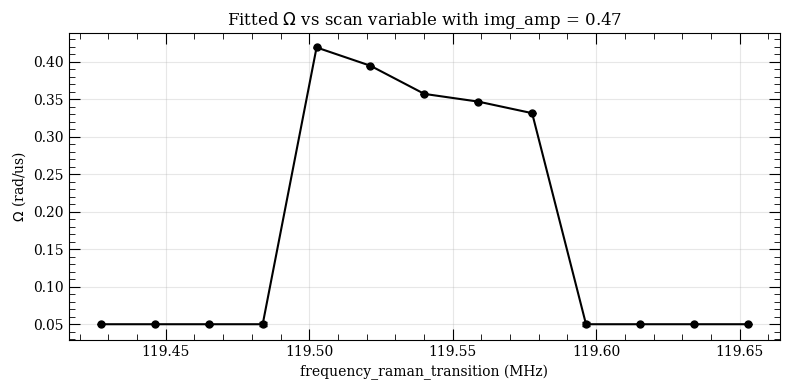

In [137]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.errorbar(
    df_fit_1["xval"],
    df_fit_1["Omega"],
    yerr=df_fit_1["Omega_err"],   # 👈 fitting uncertainty
    fmt="o-",
    color="k",
    capsize=3,
    elinewidth=1,
    markersize=5
)

ax.set_xlabel(f"{xvarname} ({xvarunit})" if xvarunit else xvarname)
ax.set_ylabel(r"$\Omega$ (rad/us)")
ax.set_title(r"Fitted $\Omega$ vs scan variable with img_amp = " + f"{ad.params.amp_imaging:.2f}")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### first fitting version (with Thomas's model) 

In [ ]:
def fit_both_models(
    t, y, tmin=None, tmax=None,
    omega_min=0.05,
    omega_max=2.0,
    fft_score_threshold=2.0,
    visibility_threshold=0.003,
    rss_ratio_threshold=1.0005):
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.ones_like(t, dtype=bool)
    if tmin is not None:
        mask &= (t >= tmin)
    if tmax is not None:
        mask &= (t <= tmax)

    t_fit = t[mask]
    y_fit = y[mask]

    if len(t_fit) < 10:
        raise RuntimeError("Not enough points")

    tail_len = max(10, len(y_fit)//10)
    y_tail = np.median(y_fit[-tail_len:])
    n0 = np.sqrt(max(y_tail, 1e-8))

    A0 = max(0.1, 0.2*n0)
    tau0 = max((t_fit[-1] - t_fit[0]) / 5, 1.0)

    y0 = np.median(y_fit[:max(10, len(y_fit)//20)])
    y1 = np.max(y_fit)
    thr = y0 + 0.1*(y1-y0)
    idx = np.where(y_fit > thr)[0]
    t00 = t_fit[idx[0]] if len(idx)>0 else 0.0

    popt_noosc, pcov_noosc = curve_fit(
        model_noosc,
        t_fit,
        y_fit,
        p0=[n0, A0, tau0, t00],
        bounds=(
            [0, -np.inf, 1e-6, np.min(t_fit)-20],
            [np.inf, np.inf, np.inf, np.max(t_fit)+20]
        ),
        maxfev=100000
    )

    perr_noosc = np.sqrt(np.diag(pcov_noosc))

    y_noosc = model_noosc(t_fit, *popt_noosc)
    residual = y_fit - y_noosc
    rss_noosc = np.sum(residual**2)

    Omega0, fft_score = estimate_omega_fft(t_fit, residual, omega_min, omega_max)

    try:
        popt_osc, pcov_osc = curve_fit(
            model_osc,
            t_fit,
            y_fit,
            p0=[n0, np.std(residual), tau0, Omega0, 0.0, t00],
            bounds=(
                [0, -np.inf, 1e-6, omega_min, -2*np.pi, np.min(t_fit)-20],
                [np.inf, np.inf, np.inf, omega_max, 2*np.pi, np.max(t_fit)+20]
            ),
            maxfev=200000
        )

        perr_osc = np.sqrt(np.diag(pcov_osc))

        y_osc = model_osc(t_fit, *popt_osc)
        rss_osc = np.sum((y_fit - y_osc)**2)

        n, A, tau, Omega, phi, t0 = popt_osc
        visibility = abs(A)/(abs(n)+1e-9)
        rss_ratio = rss_noosc / rss_osc if rss_osc > 0 else np.inf

        prefer_osc = (
            (fft_score > fft_score_threshold)
            or (
                (rss_ratio > rss_ratio_threshold)
                and (visibility > visibility_threshold)
            )
        )

        success_osc = True

    except Exception:
        popt_osc = None
        pcov_osc = None
        perr_osc = None
        rss_osc = np.inf
        visibility = 0.0
        rss_ratio = 0.0
        prefer_osc = False
        success_osc = False

    return {
        "success_osc": success_osc,
        "popt_osc": popt_osc,
        "pcov_osc": pcov_osc,
        "perr_osc": perr_osc,
        "rss_osc": rss_osc,

        "success_noosc": True,
        "popt_noosc": popt_noosc,
        "pcov_noosc": pcov_noosc,
        "perr_noosc": perr_noosc,
        "rss_noosc": rss_noosc,

        "fft_score": fft_score,
        "Omega0_fft": Omega0,
        "visibility": visibility,
        "rss_ratio": rss_ratio,
        "prefer_osc": prefer_osc
    }

In [99]:
t_us = trace.t[0] * 1e6

xvarunit, xvarmult, xvarname = detect_unit(ad, 0, xvarunit="", xvarmult=1.)

labels = [
    f"{ad.xvars[0][i * ad.params.N_repeats] * xvarmult:.3f} {xvarunit}"
    for i in range(int(ad.xvardims[0] / ad.params.N_repeats))
]

xvals = np.array([
    ad.xvars[0][i * ad.params.N_repeats] * xvarmult
    for i in range(int(ad.xvardims[0] / ad.params.N_repeats))
], dtype=float)

ncurves = min(len(averaged_traces), len(labels))
averaged_traces_use = np.asarray(averaged_traces[:ncurves])
labels_use = labels[:ncurves]
xvals_use = xvals[:ncurves]

all_results = []
rows = []

for i, y in enumerate(averaged_traces_use):
    res = fit_both_models(
        t_us,
        y,
        tmin=-10,
        tmax=300,
        omega_min=0.05,
        omega_max=2.0,
        fft_score_threshold=2.0,
        visibility_threshold=0.003,
        rss_ratio_threshold=1.0005
    )

    all_results.append(res)

    row = {
        "index": i,
        "label": labels_use[i],
        "xval": xvals_use[i],
        "prefer_osc": res["prefer_osc"],
        "fft_score": res["fft_score"],
        "visibility": res["visibility"],
        "rss_ratio": res["rss_ratio"],
    }

    if res["success_osc"]:
        n, A, tau, Omega, phi, t0 = res["popt_osc"]
        n_err, A_err, tau_err, Omega_err, phi_err, t0_err = res["perr_osc"]

        row.update({
            "n_osc": n,
            "A_osc": A,
            "tau_osc": tau,
            "Omega_osc": Omega,
            "phi_osc": phi,
            "t0_osc": t0,
            "f_osc_MHz": Omega / (2*np.pi),

            "n_osc_err": n_err,
            "A_osc_err": A_err,
            "tau_osc_err": tau_err,
            "Omega_osc_err": Omega_err,
            "phi_osc_err": phi_err,
            "t0_osc_err": t0_err,
            "f_osc_MHz_err": Omega_err / (2*np.pi),
        })
    else:
        row.update({
            "n_osc": np.nan,
            "A_osc": np.nan,
            "tau_osc": np.nan,
            "Omega_osc": np.nan,
            "phi_osc": np.nan,
            "t0_osc": np.nan,
            "f_osc_MHz": np.nan,

            "n_osc_err": np.nan,
            "A_osc_err": np.nan,
            "tau_osc_err": np.nan,
            "Omega_osc_err": np.nan,
            "phi_osc_err": np.nan,
            "t0_osc_err": np.nan,
            "f_osc_MHz_err": np.nan,
        })

    if res["success_noosc"]:
        n, A, tau, t0 = res["popt_noosc"]
        n_err, A_err, tau_err, t0_err = res["perr_noosc"]

        row.update({
            "n_noosc": n,
            "A_noosc": A,
            "tau_noosc": tau,
            "t0_noosc": t0,

            "n_noosc_err": n_err,
            "A_noosc_err": A_err,
            "tau_noosc_err": tau_err,
            "t0_noosc_err": t0_err,
        })
    else:
        row.update({
            "n_noosc": np.nan,
            "A_noosc": np.nan,
            "tau_noosc": np.nan,
            "t0_noosc": np.nan,

            "n_noosc_err": np.nan,
            "A_noosc_err": np.nan,
            "tau_noosc_err": np.nan,
            "t0_noosc_err": np.nan,
        })

    rows.append(row)

df_fit = pd.DataFrame(rows)

df_fit["Omega_selected"] = np.where(
    df_fit["prefer_osc"] & np.isfinite(df_fit["Omega_osc"]),
    df_fit["Omega_osc"],
    0.0
)

df_fit["Omega_selected_err"] = np.where(
    df_fit["prefer_osc"] & np.isfinite(df_fit["Omega_osc_err"]),
    df_fit["Omega_osc_err"],
    0.0
)

df_fit["f_selected_MHz"] = df_fit["Omega_selected"] / (2 * np.pi)
df_fit["f_selected_MHz_err"] = df_fit["Omega_selected_err"] / (2 * np.pi)

print(df_fit)

    index        label        xval  prefer_osc  fft_score  visibility  \
0       0  119.427 MHz  119.427423        True   4.153263    0.017170   
1       1  119.446 MHz  119.446205        True   3.702796    0.424841   
2       2  119.465 MHz  119.464986        True   4.735607    0.032588   
3       3  119.484 MHz  119.483768        True   4.118266    0.026611   
4       4  119.503 MHz  119.502550        True   3.837889    0.503796   
5       5  119.521 MHz  119.521331        True   3.285106    0.404368   
6       6  119.540 MHz  119.540113        True   7.301424    0.530686   
7       7  119.559 MHz  119.558895        True   5.796708    0.169691   
8       8  119.578 MHz  119.577676        True   3.921409    0.116735   
9       9  119.596 MHz  119.596458        True   3.878171    0.055797   
10     10  119.615 MHz  119.615240        True   3.423723    0.160696   
11     11  119.634 MHz  119.634021        True   3.583617    0.013896   
12     12  119.653 MHz  119.652803        True   3.

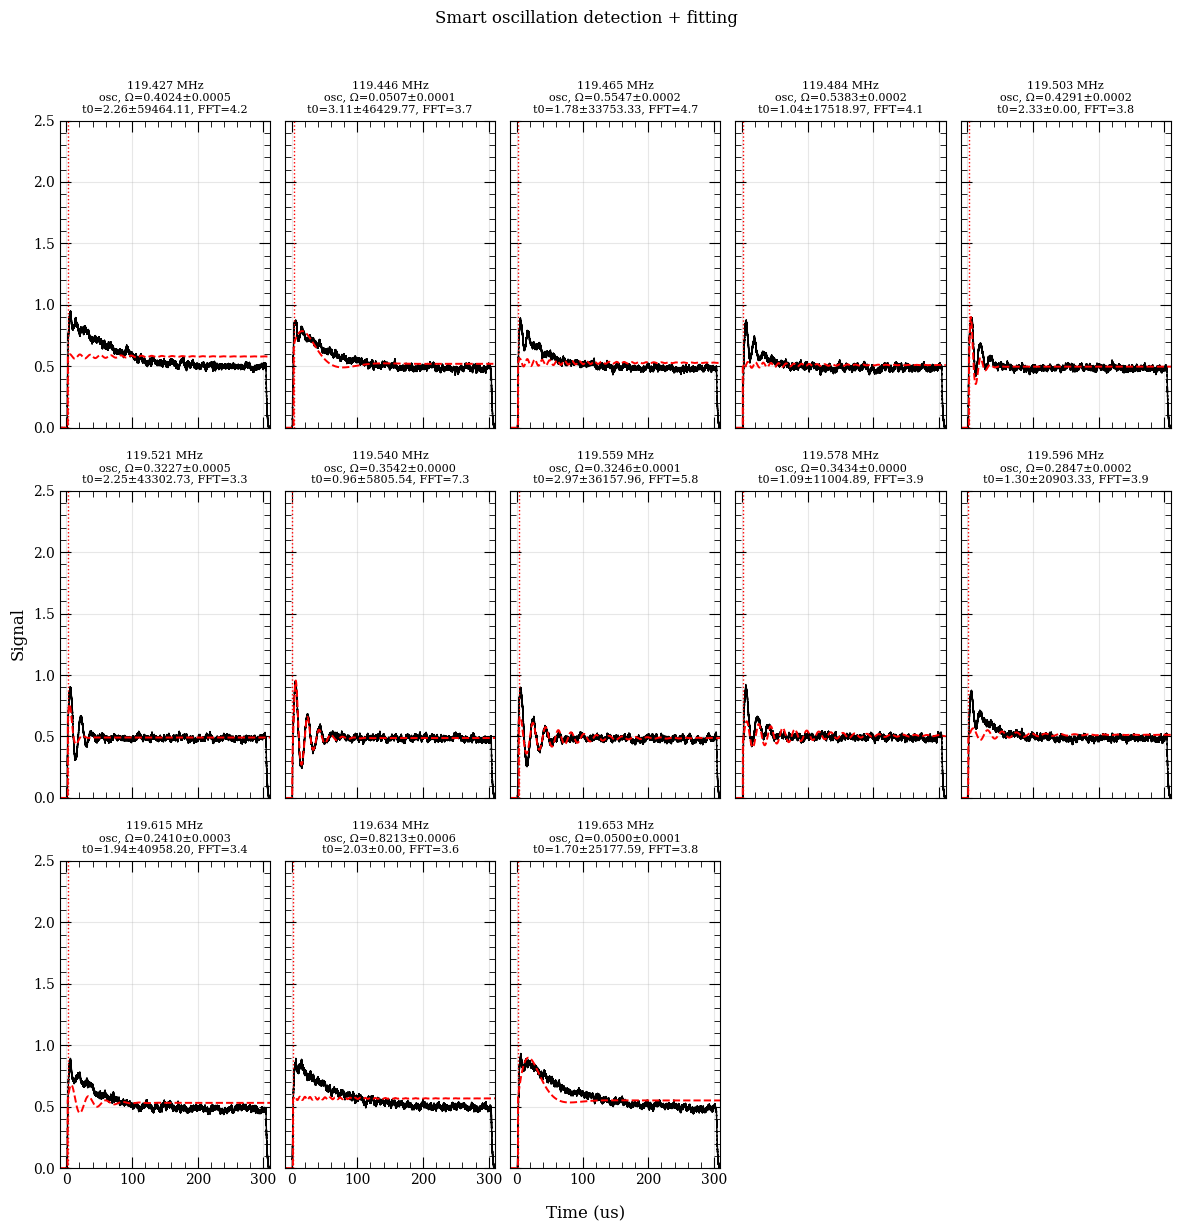

In [100]:
ncols = 5
nrows = int(np.ceil(ncurves / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 12), sharex=True, sharey=True)
axes = np.ravel(axes)

for i, y in enumerate(averaged_traces_use):
    ax = axes[i]
    res = all_results[i]

    ax.plot(t_us, y, color="k", lw=1.0)

    if res["prefer_osc"] and res["success_osc"] and res["popt_osc"] is not None:
        popt = res["popt_osc"]
        perr = res["perr_osc"]

        y_model = model_osc(t_us, *popt)
        ax.plot(t_us, y_model, "--", color="r", lw=1.4)

        n, A, tau, Omega, phi, t0 = popt
        n_err, A_err, tau_err, Omega_err, phi_err, t0_err = perr

        ax.axvline(t0, color="r", ls=":", lw=1)

        ax.set_title(
            f"{labels_use[i]}\n"
            f"osc, Ω={Omega:.4f}±{Omega_err:.4f}\n"
            f"t0={t0:.2f}±{t0_err:.2f}, FFT={res['fft_score']:.1f}",
            fontsize=8
        )

    elif res["success_noosc"] and res["popt_noosc"] is not None:
        popt = res["popt_noosc"]
        perr = res["perr_noosc"]

        y_model = model_noosc(t_us, *popt)
        ax.plot(t_us, y_model, color="g", lw=1.4)

        n, A, tau, t0 = popt
        n_err, A_err, tau_err, t0_err = perr

        ax.axvline(t0, color="b", ls=":", lw=1)

        ax.set_title(
            f"{labels_use[i]}\n"
            f"no osc\n"
            f"t0={t0:.2f}±{t0_err:.2f}, FFT={res['fft_score']:.1f}",
            fontsize=8
        )

    else:
        ax.set_title(f"{labels_use[i]}\nfit failed", fontsize=8)

    ax.set_xlim(-10, 310)
    ax.set_ylim(0, 2.5)
    ax.grid(alpha=0.3)

for j in range(ncurves, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Smart oscillation detection + fitting", y=1.02)
fig.supxlabel("Time (us)")
fig.supylabel("Signal")

plt.tight_layout()
plt.show()

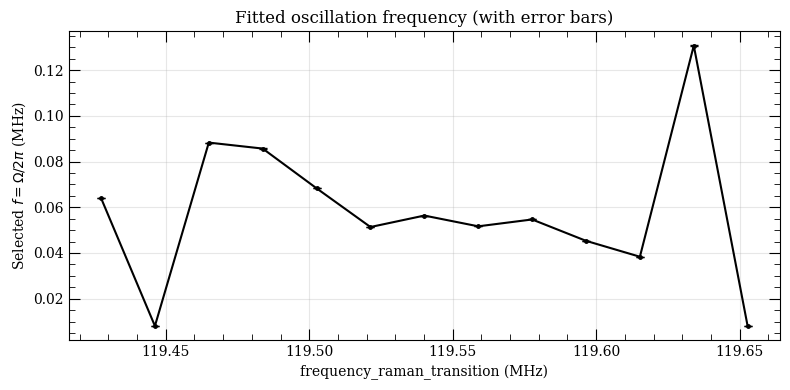

In [107]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.errorbar(
    df_fit["xval"],
    df_fit["f_selected_MHz"],
    yerr=df_fit["f_selected_MHz_err"],   
    fmt=".-",                         
    color="k",
    capsize=3,                          
    elinewidth=1,
    markersize=5
)

ax.set_xlabel(f"{xvarname} ({xvarunit})" if xvarunit else xvarname)
ax.set_ylabel(r"Selected $f=\Omega/2\pi$ (MHz)")
ax.set_title("Fitted oscillation frequency (with error bars)")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

label: 119.427 MHz
prefer_osc: True
fft_score: 4.153262810178336
visibility: 0.017169956805600264
rss_ratio: 0.14166390100219833

Osc fit:
n     = 0.761231
A     = 0.0130703
tau   = 104.258 us
Omega = 0.402376 rad/us
f     = 0.0640402 MHz
phi   = -1.13441
t0    = 2.258 us

No-osc fit:
n   = 0.684797
A   = 0.24446
tau = 93.5165 us
t0  = 1.33629 us


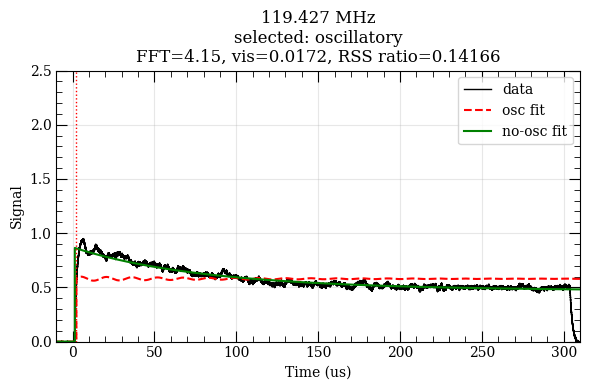

In [94]:
# Fit one specific curve and tune criteria

i = 0
y = averaged_traces_use[i]

fit_kwargs = dict(
    tmin=-10,
    tmax=300,
    omega_min=0.05,
    omega_max=2.0,
    fft_score_threshold=1.5,     
    visibility_threshold=0.001, 
    rss_ratio_threshold=1.0001   
)

res = fit_both_models(
    t_us,
    y,
    **fit_kwargs
)

print("label:", labels_use[i])
print("prefer_osc:", res["prefer_osc"])
print("fft_score:", res["fft_score"])
print("visibility:", res["visibility"])
print("rss_ratio:", res["rss_ratio"])

if res["success_osc"]:
    n, A, tau, Omega, phi, t0 = res["popt_osc"]
    print("\nOsc fit:")
    print(f"n     = {n:.6g}")
    print(f"A     = {A:.6g}")
    print(f"tau   = {tau:.6g} us")
    print(f"Omega = {Omega:.6g} rad/us")
    print(f"f     = {Omega/(2*np.pi):.6g} MHz")
    print(f"phi   = {phi:.6g}")
    print(f"t0    = {t0:.6g} us")

if res["success_noosc"]:
    n, A, tau, t0 = res["popt_noosc"]
    print("\nNo-osc fit:")
    print(f"n   = {n:.6g}")
    print(f"A   = {A:.6g}")
    print(f"tau = {tau:.6g} us")
    print(f"t0  = {t0:.6g} us")


plt.figure(figsize=(6, 4))
plt.plot(t_us, y, color="k", lw=1.0, label="data")

if res["success_osc"]:
    plt.plot(
        t_us,
        model_osc(t_us, *res["popt_osc"]),
        "r--",
        lw=1.5,
        label="osc fit"
    )

if res["success_noosc"]:
    plt.plot(
        t_us,
        model_noosc(t_us, *res["popt_noosc"]),
        color="g",
        lw=1.5,
        label="no-osc fit"
    )

if res["prefer_osc"] and res["success_osc"]:
    t0_plot = res["popt_osc"][-1]
    plt.axvline(t0_plot, color="r", ls=":", lw=1)
    title_status = "selected: oscillatory"
else:
    t0_plot = res["popt_noosc"][-1]
    plt.axvline(t0_plot, color="g", ls=":", lw=1)
    title_status = "selected: non-oscillatory"

plt.title(
    f"{labels_use[i]}\n"
    f"{title_status}\n"
    f"FFT={res['fft_score']:.2f}, vis={res['visibility']:.4f}, RSS ratio={res['rss_ratio']:.5f}"
)

plt.xlabel("Time (us)")
plt.ylabel("Signal")
plt.xlim(-10, 310)
plt.ylim(0, 2.5)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

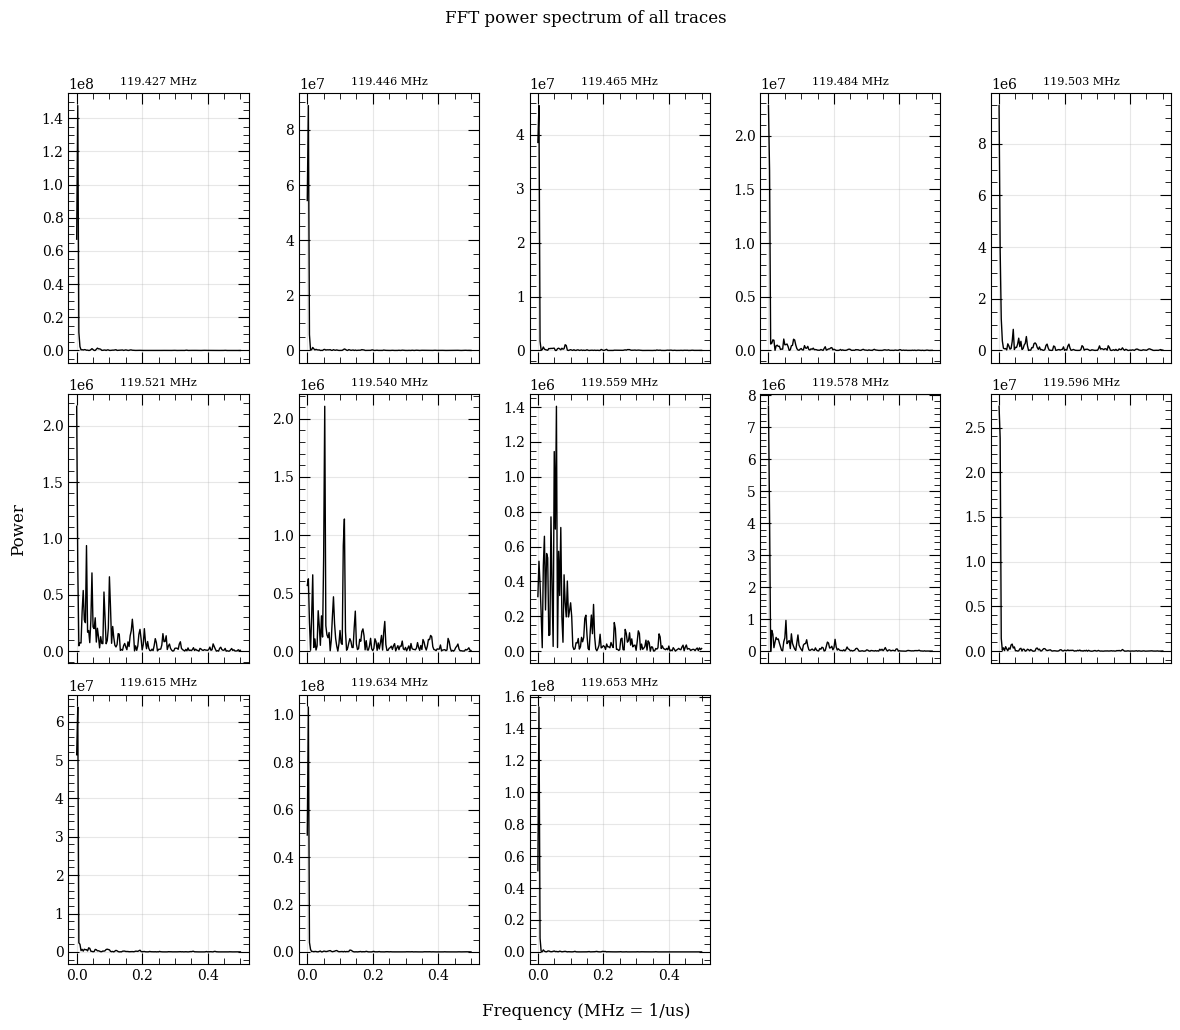

In [139]:
import numpy as np
import matplotlib.pyplot as plt

# time axis in us
t_us = trace.t[0] * 1e6

# frequency window to display
fmin = 0.0      # MHz = 1/us
fmax = 0.5      # adjust if needed

def compute_fft_spectrum(t, y, tmin=0, tmax=300, subtract_mean=True, window=True):
    mask = (t >= tmin) & (t <= tmax)

    tt = t[mask]
    yy = y[mask]

    if subtract_mean:
        yy = yy - np.mean(yy)

    if window:
        yy = yy * np.hanning(len(yy))

    dt = np.median(np.diff(tt))

    freqs = np.fft.rfftfreq(len(tt), d=dt)   # cycles/us = MHz
    fft_vals = np.fft.rfft(yy)

    power = np.abs(fft_vals)**2
    omega = 2 * np.pi * freqs                # rad/us

    return freqs, omega, power


ncols = 5
ncurves = len(averaged_traces_use)
nrows = int(np.ceil(ncurves / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 10), sharex=True, sharey=False)
axes = np.ravel(axes)

fft_results = []

for i, y in enumerate(averaged_traces_use):
    freqs, omega, power = compute_fft_spectrum(
        t_us,
        y,
        tmin=0,
        tmax=300,
        subtract_mean=True,
        window=True
    )

    fft_results.append({
        "index": i,
        "freqs_MHz": freqs,
        "omega_rad_per_us": omega,
        "power": power
    })

    ax = axes[i]

    mask_f = (freqs >= fmin) & (freqs <= fmax)

    ax.plot(freqs[mask_f], power[mask_f], color="k", lw=1.0)

    ax.set_title(labels_use[i], fontsize=8)
    ax.grid(alpha=0.3)

for j in range(ncurves, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("FFT power spectrum of all traces", y=1.02)
fig.supxlabel("Frequency (MHz = 1/us)")
fig.supylabel("Power")

plt.tight_layout()
plt.show()

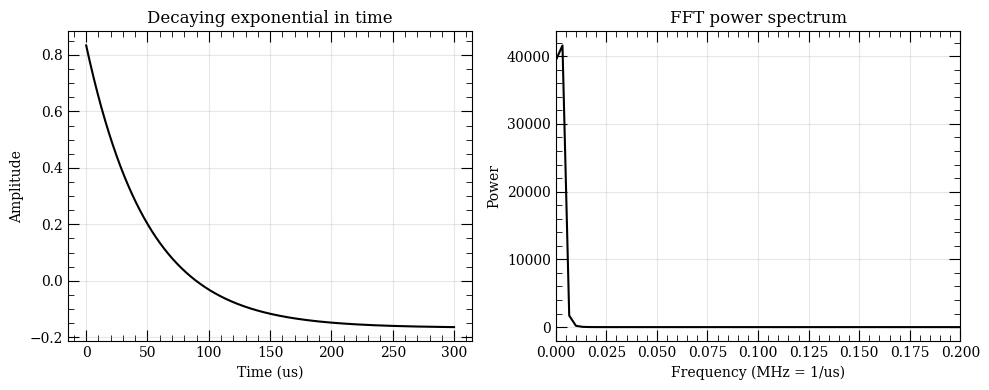

In [140]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- parameters ----------
tau = 50.0          # decay time (us)
t_max = 300.0       # total time window (us)
N = 5000            # number of points

# ---------- time axis ----------
t = np.linspace(0, t_max, N)
dt = t[1] - t[0]

# ---------- signal ----------
y = np.exp(-t / tau)

# optional: subtract mean to reduce DC spike
y = y - np.mean(y)

# optional: apply window to reduce leakage
window = np.hanning(N)
y_win = y * window

# ---------- FFT ----------
fft_vals = np.fft.rfft(y_win)
freqs = np.fft.rfftfreq(N, d=dt)   # MHz if t in us
omega = 2 * np.pi * freqs          # rad/us

power = np.abs(fft_vals)**2

# ---------- plot ----------
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# time domain
axes[0].plot(t, y, color="k")
axes[0].set_title("Decaying exponential in time")
axes[0].set_xlabel("Time (us)")
axes[0].set_ylabel("Amplitude")
axes[0].grid(alpha=0.3)

# frequency domain
axes[1].plot(freqs, power, color="k")
axes[1].set_xlim(0, 0.2)  # zoom low-frequency region
axes[1].set_title("FFT power spectrum")
axes[1].set_xlabel("Frequency (MHz = 1/us)")
axes[1].set_ylabel("Power")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [152]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit

def time_model(t, A, Omega, tau, phi, t0, C):
    tt = t - t0
    H = (tt >= 0).astype(float)
    return H * A * np.exp(-tt / tau) * np.cos(Omega * tt + phi) + C

def finite_ft_model(omega, A, Omega, tau, phi, t0, C, tmin, tmax):
    alpha = 1.0 / tau

    L = np.maximum(tmin - t0, 0.0)
    U = np.maximum(tmax - t0, 0.0)

    phase_shift = np.exp(-1j * omega * t0)

    q_plus = alpha + 1j * (omega - Omega)
    q_minus = alpha + 1j * (omega + Omega)

    I_plus = (np.exp(-q_plus * L) - np.exp(-q_plus * U)) / q_plus
    I_minus = (np.exp(-q_minus * L) - np.exp(-q_minus * U)) / q_minus

    osc_part = 0.5 * A * phase_shift * (
        np.exp(1j * phi) * I_plus +
        np.exp(-1j * phi) * I_minus
    )

    const_part = np.zeros_like(omega, dtype=complex)
    small = np.abs(omega) < 1e-12

    const_part[small] = C * (tmax - tmin)

    const_part[~small] = C * (
        np.exp(-1j * omega[~small] * tmin)
        - np.exp(-1j * omega[~small] * tmax)
    ) / (1j * omega[~small])

    return osc_part + const_part


def fit_fft_one_trace(
    t, y,
    tmin=0,
    tmax=300,
    fmin=0.005,
    fmax=0.5,
    omega_bounds=(0.05, 2.0)
):
    mask_t = (t >= tmin) & (t <= tmax)
    tt = t[mask_t]
    yy = y[mask_t]

    dt = np.median(np.diff(tt))

    Y = np.fft.rfft(yy) * dt
    freqs = np.fft.rfftfreq(len(tt), d=dt)
    omega = 2 * np.pi * freqs

    mask_f = (freqs >= fmin) & (freqs <= fmax)
    omega_fit = omega[mask_f]
    Y_fit = Y[mask_f]

    C0 = np.median(yy[-max(10, len(yy)//10):])
    A0 = np.max(yy) - np.min(yy)
    tau0 = max((tmax - tmin) / 5, 1.0)

    idx_peak = np.argmax(np.abs(Y_fit))
    Omega0 = omega_fit[idx_peak]
    phi0 = 0.0
    t00 = 0.0

    lower = [-np.inf, omega_bounds[0], 1e-6, -2*np.pi, tmin - 20, -np.inf]
    upper = [ np.inf, omega_bounds[1], np.inf,  2*np.pi, tmax + 20,  np.inf]

    Omega0 = np.clip(Omega0, omega_bounds[0] + 1e-9, omega_bounds[1] - 1e-9)
    tau0 = max(tau0, 1e-6)
    phi0 = np.clip(phi0, -2*np.pi + 1e-9, 2*np.pi - 1e-9)
    t00 = np.clip(t00, tmin - 20 + 1e-9, tmax + 20 - 1e-9)

    p0 = [A0, Omega0, tau0, phi0, t00, C0]

    def complex_fft_fit_function(omega_input, A, Omega, tau, phi, t0, C):
        Y_model = finite_ft_model(
            omega_input, A, Omega, tau, phi, t0, C, tmin, tmax
        )
        return np.concatenate([Y_model.real, Y_model.imag])

    ydata = np.concatenate([Y_fit.real, Y_fit.imag])

    popt, pcov = curve_fit(
        complex_fft_fit_function,
        omega_fit,
        ydata,
        p0=p0,
        bounds=(lower, upper),
        maxfev=200000
    )

    perr = np.sqrt(np.diag(pcov))

    return {
        "success": True,
        "popt": popt,
        "perr": perr,
        "pcov": pcov,
        "tt": tt,
        "yy": yy,
        "freqs": freqs,
        "omega": omega,
        "Y": Y,
        "omega_fit": omega_fit,
        "Y_fit": Y_fit,
        "tmin": tmin,
        "tmax": tmax,
    }

In [153]:
t_us = trace.t[0] * 1e6

xvarunit, xvarmult, xvarname = detect_unit(ad, 0, xvarunit="", xvarmult=1.)

labels = [
    f"{ad.xvars[0][i * ad.params.N_repeats] * xvarmult:.3f} {xvarunit}"
    for i in range(int(ad.xvardims[0] / ad.params.N_repeats))
]

xvals = np.array([
    ad.xvars[0][i * ad.params.N_repeats] * xvarmult
    for i in range(int(ad.xvardims[0] / ad.params.N_repeats))
], dtype=float)

ncurves = min(len(averaged_traces), len(labels))
averaged_traces_use = np.asarray(averaged_traces[:ncurves])
labels_use = labels[:ncurves]
xvals_use = xvals[:ncurves]

fft_fit_results = []
rows = []

for i, y in enumerate(averaged_traces_use):
    try:
        res = fit_fft_one_trace(
            t_us,
            y,
            tmin=0,
            tmax=300,
            fmin=0.005,
            fmax=0.5,
            omega_bounds=(0.05, 2.0)
        )

        A, Omega, tau, phi, t0, C = res["popt"]
        A_err, Omega_err, tau_err, phi_err, t0_err, C_err = res["perr"]

        fft_fit_results.append(res)

        rows.append({
            "index": i,
            "label": labels_use[i],
            "xval": xvals_use[i],
            "A": A,
            "Omega": Omega,
            "tau_us": tau,
            "phi": phi,
            "t0_us": t0,
            "C": C,
            "A_err": A_err,
            "Omega_err": Omega_err,
            "tau_us_err": tau_err,
            "phi_err": phi_err,
            "t0_us_err": t0_err,
            "C_err": C_err,
            "f_MHz": Omega / (2*np.pi),
            "f_MHz_err": Omega_err / (2*np.pi),
            "success": True
        })

    except Exception as e:
        fft_fit_results.append({
            "success": False,
            "error": str(e)
        })

        rows.append({
            "index": i,
            "label": labels_use[i],
            "xval": xvals_use[i],
            "A": np.nan,
            "Omega": np.nan,
            "tau_us": np.nan,
            "phi": np.nan,
            "t0_us": np.nan,
            "C": np.nan,
            "A_err": np.nan,
            "Omega_err": np.nan,
            "tau_us_err": np.nan,
            "phi_err": np.nan,
            "t0_us_err": np.nan,
            "C_err": np.nan,
            "f_MHz": np.nan,
            "f_MHz_err": np.nan,
            "success": False,
            "error": str(e)
        })

df_fft_fit = pd.DataFrame(rows)
print(df_fft_fit)

    index        label        xval         A     Omega     tau_us       phi  \
0       0  119.427 MHz  119.427423  0.668690  0.050000  20.860832 -1.288284   
1       1  119.446 MHz  119.446205  0.561298  0.050000  21.635813 -1.234397   
2       2  119.465 MHz  119.464986  0.490480  0.050000  20.827981 -1.144874   
3       3  119.484 MHz  119.483768  0.136932  0.050000  29.567849 -0.261978   
4       4  119.503 MHz  119.502550  0.474152  0.050000   8.962441 -0.724581   
5       5  119.521 MHz  119.521331 -0.792290  0.391294  11.691620  0.296725   
6       6  119.540 MHz  119.540113 -0.709753  0.357122  16.201074  0.568640   
7       7  119.559 MHz  119.558895 -0.700400  0.346723  15.628926  0.492527   
8       8  119.578 MHz  119.577676 -0.981788  0.354924   7.000361  0.702476   
9       9  119.596 MHz  119.596458  0.149415  0.050000  30.524064 -0.318910   
10     10  119.615 MHz  119.615240  0.531112  0.050000  21.735495 -1.215939   
11     11  119.634 MHz  119.634021 -0.624708  0.0500

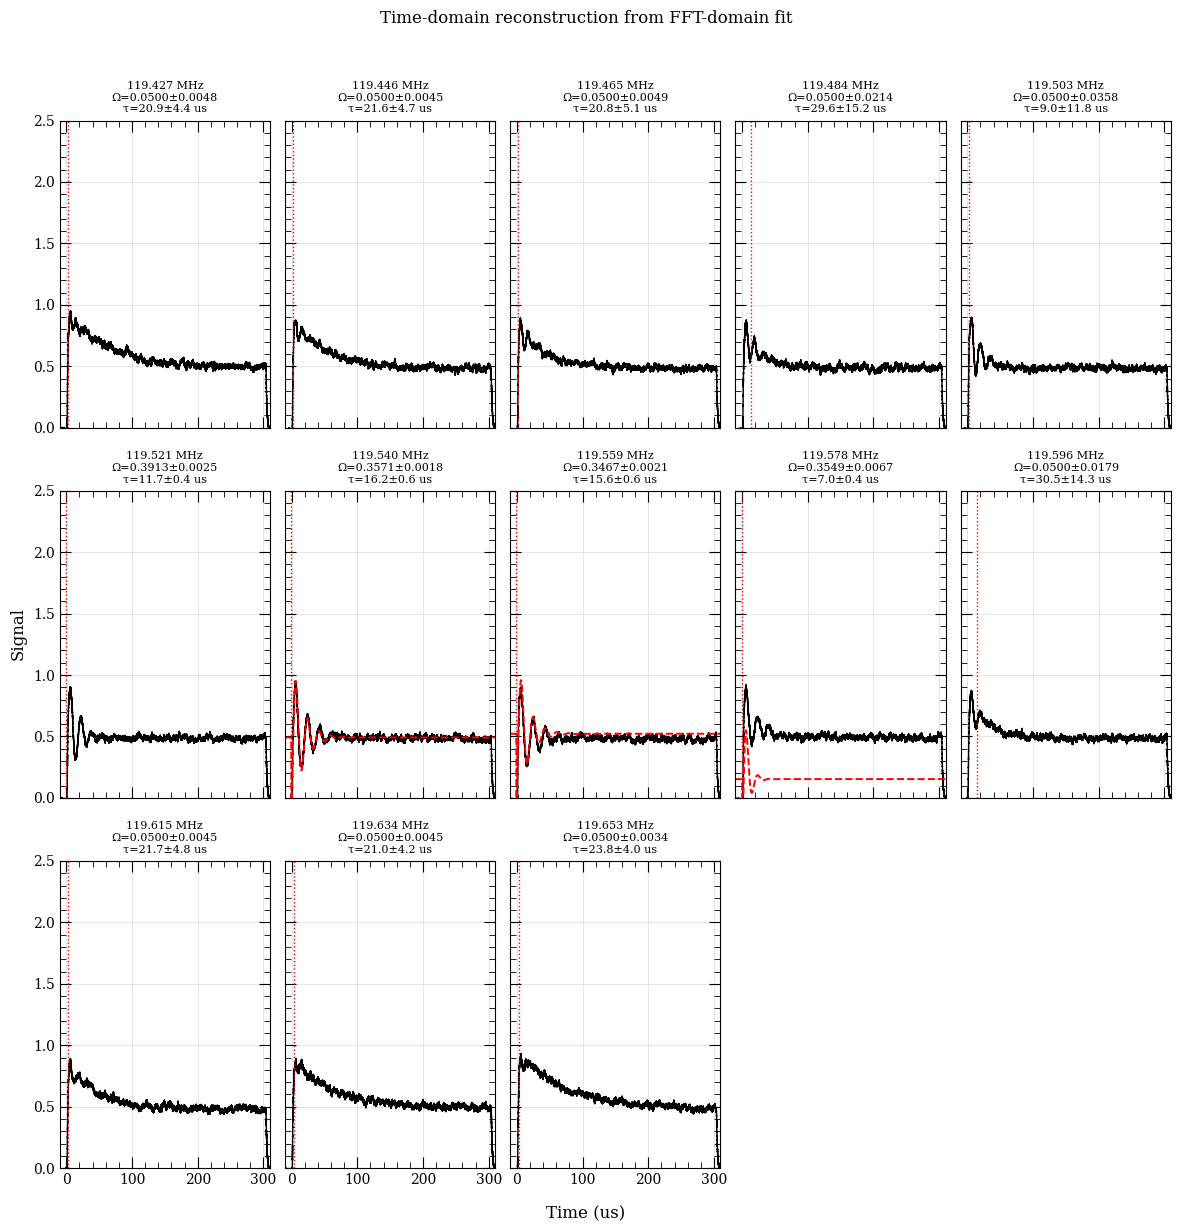

In [154]:
ncols = 5
nrows = int(np.ceil(ncurves / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 12), sharex=True, sharey=True)
axes = np.ravel(axes)

for i, y in enumerate(averaged_traces_use):
    ax = axes[i]
    res = fft_fit_results[i]

    ax.plot(t_us, y, color="k", lw=1.0)

    if res["success"]:
        popt = res["popt"]
        perr = res["perr"]

        y_model = time_model(t_us, *popt)
        ax.plot(t_us, y_model, "r--", lw=1.4)

        A, Omega, tau, phi, t0, C = popt
        A_err, Omega_err, tau_err, phi_err, t0_err, C_err = perr

        ax.axvline(t0, color="r", ls=":", lw=1)

        ax.set_title(
            f"{labels_use[i]}\n"
            f"Ω={Omega:.4f}±{Omega_err:.4f}\n"
            f"τ={tau:.1f}±{tau_err:.1f} us",
            fontsize=8
        )
    else:
        ax.set_title(f"{labels_use[i]}\nfit failed", fontsize=8)

    ax.set_xlim(-10, 310)
    ax.set_ylim(0, 2.5)
    ax.grid(alpha=0.3)

for j in range(ncurves, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Time-domain reconstruction from FFT-domain fit", y=1.02)
fig.supxlabel("Time (us)")
fig.supylabel("Signal")

plt.tight_layout()
plt.show()

In [197]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit

def H(x):
    return (x >= 0).astype(float)

def model_heaviside_decay_sine(t, A, alpha, B, beta, omega, phi, C, delta):
    return H(t - delta) * (
        A * np.exp(-alpha * t)
        + B * np.exp(-beta * t) * np.sin(omega * t + phi)
        + C
    )

def fit_single_heaviside_decay_sine(
    t, y,
    tmin=-10,
    tmax=300,
    omega_min=0.05,
    omega_max=2.0,
    alpha_min=0.0,
    alpha_max=1.0,
    beta_min=0.0,
    beta_max=1.0,
    delta_min=-20,
    delta_max=50
):
    t = np.asarray(t, float)
    y = np.asarray(y, float)

    mask = (t >= tmin) & (t <= tmax)
    t_fit = t[mask]
    y_fit = y[mask]

    if len(t_fit) < 20:
        raise RuntimeError("Not enough fitting points.")

    C0 = np.median(y_fit[-max(10, len(y_fit)//10):])
    A0 = y_fit[0] - C0
    B0 = 0.25 * (np.max(y_fit) - np.min(y_fit))

    alpha0 = 1 / 80.0
    beta0 = 1 / 80.0
    omega0 = 2 * np.pi / 20.0
    phi0 = 0.0

    y_base = np.median(y_fit[:max(10, len(y_fit)//20)])
    y_max = np.max(y_fit)
    threshold = y_base + 0.1 * (y_max - y_base)
    idx = np.where(y_fit > threshold)[0]
    delta0 = t_fit[idx[0]] if len(idx) > 0 else 0.0

    omega0 = np.clip(omega0, omega_min + 1e-9, omega_max - 1e-9)
    alpha0 = np.clip(alpha0, alpha_min + 1e-9, alpha_max - 1e-9)
    beta0 = np.clip(beta0, beta_min + 1e-9, beta_max - 1e-9)
    delta0 = np.clip(delta0, delta_min + 1e-9, delta_max - 1e-9)

    p0 = [A0, alpha0, B0, beta0, omega0, phi0, C0, delta0]

    bounds = (
        [-np.inf, alpha_min, -np.inf, beta_min, omega_min, -2*np.pi, -np.inf, delta_min],
        [ np.inf, alpha_max,  np.inf, beta_max, omega_max,  2*np.pi,  np.inf, delta_max]
    )

    popt, pcov = curve_fit(
        model_heaviside_decay_sine,
        t_fit,
        y_fit,
        p0=p0,
        bounds=bounds,
        maxfev=300000
    )

    perr = np.sqrt(np.diag(pcov))

    return popt, pcov, perr, t_fit, y_fit

In [198]:
import time

fit_results_heaviside = []
rows = []

decimate_fit = 20   # try 10, 20, 50. Larger = faster but less precise
start_all = time.time()

for i, y in enumerate(averaged_traces_use):
    t0_loop = time.time()
    print(f"[{i+1}/{ncurves}] fitting {labels_use[i]} ...", flush=True)

    try:
        popt, pcov, perr, t_fit, y_fit = fit_single_heaviside_decay_sine(
            t_us[::decimate_fit],
            y[::decimate_fit],
            tmin=-10,
            tmax=300,
            omega_min=0.05,
            omega_max=2.0,
            alpha_min=0.0,
            alpha_max=1.0,
            beta_min=0.0,
            beta_max=1.0,
            delta_min=-20,
            delta_max=50
        )

        A, alpha, B, beta, omega, phi, C, delta = popt
        A_err, alpha_err, B_err, beta_err, omega_err, phi_err, C_err, delta_err = perr

        fit_results_heaviside.append({
            "success": True,
            "popt": popt,
            "pcov": pcov,
            "perr": perr
        })

        rows.append({
            "index": i,
            "label": labels_use[i],
            "xval": xvals_use[i],
            "A": A,
            "alpha": alpha,
            "B": B,
            "beta": beta,
            "omega": omega,
            "phi": phi,
            "C": C,
            "delta": delta,
            "A_err": A_err,
            "alpha_err": alpha_err,
            "B_err": B_err,
            "beta_err": beta_err,
            "omega_err": omega_err,
            "phi_err": phi_err,
            "C_err": C_err,
            "delta_err": delta_err,
            "f_MHz": omega / (2*np.pi),
            "f_MHz_err": omega_err / (2*np.pi),
            "success": True
        })

        print(
            f"    done in {time.time()-t0_loop:.1f}s | "
            f"omega={omega:.4f}, delta={delta:.2f}",
            flush=True
        )

    except Exception as e:
        fit_results_heaviside.append({
            "success": False,
            "popt": None,
            "pcov": None,
            "perr": None,
            "error": str(e)
        })

        rows.append({
            "index": i,
            "label": labels_use[i],
            "xval": xvals_use[i],
            "A": np.nan,
            "alpha": np.nan,
            "B": np.nan,
            "beta": np.nan,
            "omega": np.nan,
            "phi": np.nan,
            "C": np.nan,
            "delta": np.nan,
            "A_err": np.nan,
            "alpha_err": np.nan,
            "B_err": np.nan,
            "beta_err": np.nan,
            "omega_err": np.nan,
            "phi_err": np.nan,
            "C_err": np.nan,
            "delta_err": np.nan,
            "f_MHz": np.nan,
            "f_MHz_err": np.nan,
            "success": False,
            "error": str(e)
        })

        print(f"    FAILED in {time.time()-t0_loop:.1f}s: {e}", flush=True)

df_heaviside = pd.DataFrame(rows)

print(f"\nAll done in {(time.time()-start_all)/60:.1f} min")
print(df_heaviside)

[1/13] fitting 119.427 MHz ...
    done in 0.2s | omega=0.5673, delta=1.34
[2/13] fitting 119.446 MHz ...
    done in 0.2s | omega=0.6086, delta=1.34
[3/13] fitting 119.465 MHz ...
    done in 0.3s | omega=0.5735, delta=1.32
[4/13] fitting 119.484 MHz ...
    done in 0.2s | omega=0.5185, delta=1.31
[5/13] fitting 119.503 MHz ...
    done in 0.2s | omega=0.4507, delta=1.31
[6/13] fitting 119.521 MHz ...
    done in 0.2s | omega=0.3934, delta=1.33
[7/13] fitting 119.540 MHz ...
    done in 2.5s | omega=0.3510, delta=1.33
[8/13] fitting 119.559 MHz ...
    done in 2.1s | omega=0.3404, delta=1.29
[9/13] fitting 119.578 MHz ...
    done in 0.2s | omega=0.3763, delta=1.34
[10/13] fitting 119.596 MHz ...
    done in 0.2s | omega=0.4984, delta=1.35
[11/13] fitting 119.615 MHz ...
    done in 174.7s | omega=0.5852, delta=1.33
[12/13] fitting 119.634 MHz ...
    done in 0.6s | omega=0.2076, delta=1.34
[13/13] fitting 119.653 MHz ...
    done in 0.3s | omega=0.4476, delta=1.33

All done in 3.0 mi

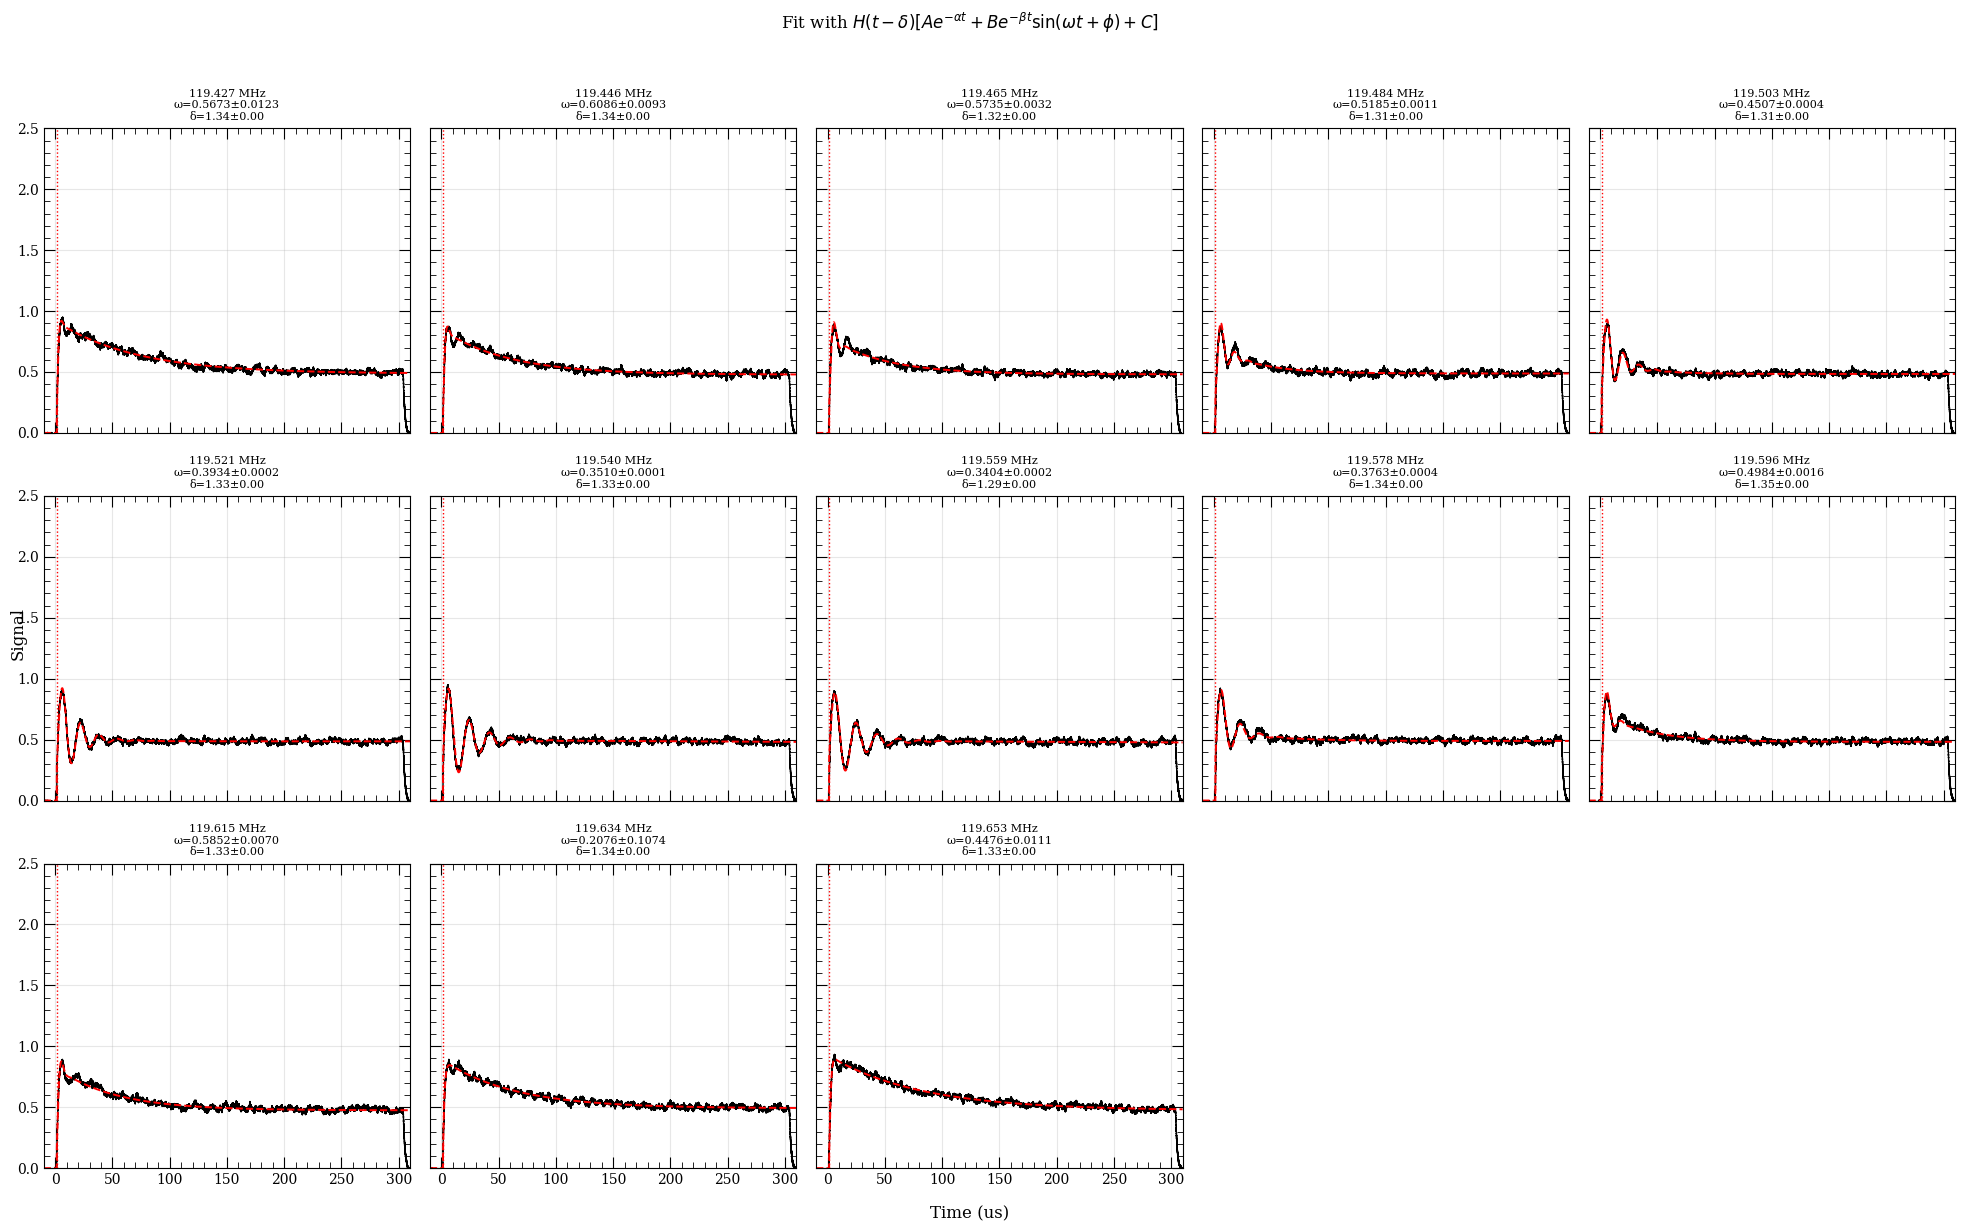

In [187]:
ncols = 5
nrows = int(np.ceil(ncurves / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(20, 12), sharex=True, sharey=True)
axes = np.ravel(axes)

for i, y in enumerate(averaged_traces_use):
    ax = axes[i]
    res = fit_results_heaviside[i]

    ax.plot(t_us, y, color="k", lw=1.0)

    if res["success"]:
        popt = res["popt"]
        perr = res["perr"]

        y_model = model_heaviside_decay_sine(t_us, *popt)
        ax.plot(t_us, y_model, "--", color="r", lw=1.4)

        A, alpha, B, beta, omega, phi, C, delta = popt
        A_err, alpha_err, B_err, beta_err, omega_err, phi_err, C_err, delta_err = perr

        ax.axvline(delta, color="r", ls=":", lw=1)

        ax.set_title(
            f"{labels_use[i]}\n"
            f"ω={omega:.4f}±{omega_err:.4f}\n"
            f"δ={delta:.2f}±{delta_err:.2f}",
            fontsize=8
        )
    else:
        ax.set_title(f"{labels_use[i]}\nfit failed", fontsize=8)

    ax.set_xlim(-10, 310)
    ax.set_ylim(0, 2.5)
    ax.grid(alpha=0.3)

for j in range(ncurves, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(
    r"Fit with $H(t-\delta)[Ae^{-\alpha t}+Be^{-\beta t}\sin(\omega t+\phi)+C]$",
    y=1.02
)
fig.supxlabel("Time (us)")
fig.supylabel("Signal")

plt.tight_layout()
plt.show()

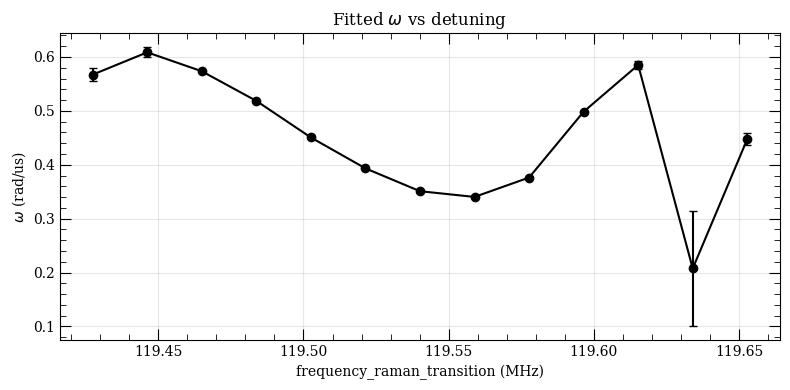

In [185]:
mask = df_heaviside["success"] & np.isfinite(df_heaviside["omega"])

fig, ax = plt.subplots(figsize=(8, 4))

ax.errorbar(
    df_heaviside.loc[mask, "xval"],
    df_heaviside.loc[mask, "omega"],
    yerr=df_heaviside.loc[mask, "omega_err"],
    fmt="o-",
    color="k",
    capsize=3
)

ax.set_xlabel(f"{xvarname} ({xvarunit})" if xvarunit else xvarname)
ax.set_ylabel(r"$\omega$ (rad/us)")
ax.set_title(r"Fitted $\omega$ vs detuning")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()